# Análisis exploratorio de COVID-19 en Estados Unidos

## Objetivo

Analizar la evolución de la pandemia en Estados Unidos, evaluar la calidad de los datos e identificar los estados y periodos con mayor impacto.

## 1. Carga de librerías y datos

Importamos las librerías necesarias y cargamos el archivo CSV con los datos históricos de COVID-19.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "all-states-history.csv"

df = pd.read_csv(DATA_PATH)

print(f"Archivo: {DATA_PATH}")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.head()

Archivo: C:\Users\migue\Documents\EDA\data\raw\all-states-history.csv
Filas: 20780
Columnas: 41


,date,state,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
0,2021-03-07,AK,305.0,NaN,0,NaN,1293.0,1293.0,33.0,0,...,1731628.0,0,NaN,NaN,NaN,NaN,NaN,0,1731628.0,0
1,2021-03-07,AL,10148.0,7963.0,-1,2185.0,45976.0,45976.0,494.0,0,...,2323788.0,2347,NaN,NaN,119757.0,NaN,2323788.0,2347,NaN,0
2,2021-03-07,AR,5319.0,4308.0,22,1011.0,14926.0,14926.0,335.0,11,...,2736442.0,3380,NaN,NaN,NaN,481311.0,NaN,0,2736442.0,3380
3,2021-03-07,AS,0.0,NaN,0,NaN,NaN,NaN,NaN,0,...,2140.0,0,NaN,NaN,NaN,NaN,NaN,0,2140.0,0
4,2021-03-07,AZ,16328.0,14403.0,5,1925.0,57907.0,57907.0,963.0,44,...,7908105.0,45110,580569.0,NaN,444089.0,NaN,3842945.0,14856,7908105.0,45110


## 2. Comprensión inicial del dataset

Antes de limpiar los datos, revisamos su estructura, tipos de variables, periodo temporal, estados incluidos y posibles duplicados.

In [5]:
print(f"Dimensiones: {df.shape}")
print(f"Fecha mínima: {df['date'].min()}")
print(f"Fecha máxima: {df['date'].max()}")
print(f"Estados y territorios: {df['state'].nunique()}")
print(f"Duplicados completos: {df.duplicated().sum()}")

df.info()

Dimensiones: (20780, 41)
Fecha mínima: 2020-01-13
Fecha máxima: 2021-03-07
Estados y territorios: 56
Duplicados completos: 0
<class 'pandas.DataFrame'>
RangeIndex: 20780 entries, 0 to 20779
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   date                              20780 non-null  str    
 1   state                             20780 non-null  str    
 2   death                             19930 non-null  float64
 3   deathConfirmed                    9422 non-null   float64
 4   deathIncrease                     20780 non-null  int64  
 5   deathProbable                     7593 non-null   float64
 6   hospitalized                      12382 non-null  float64
 7   hospitalizedCumulative            12382 non-null  float64
 8   hospitalizedCurrently             17339 non-null  float64
 9   hospitalizedIncrease              20780 non-null  int64  
 10  inIcuCumulative 

### Observaciones iniciales

- El dataset contiene 20.780 registros y 41 variables.
- Comprende el periodo entre el 13 de enero de 2020 y el 7 de marzo de 2021.
- Incluye 56 estados y territorios.
- No se encontraron filas completamente duplicadas.
- La columna `date` está almacenada como texto y deberá convertirse a formato fecha.
- Existen numerosos valores ausentes, especialmente en las variables relacionadas con pruebas específicas, UCI y ventilación.

In [6]:
df["date"] = pd.to_datetime(df["date"])

duplicados_fecha_estado = df.duplicated(
    subset=["date", "state"]
).sum()

print(f"Tipo de date: {df['date'].dtype}")
print(f"Duplicados por fecha y estado: {duplicados_fecha_estado}")

Tipo de date: datetime64[us]
Duplicados por fecha y estado: 0


## 3. Análisis de valores ausentes

Calculamos el porcentaje de datos ausentes por columna. Esto permitirá descartar variables con una cobertura insuficiente y evitar conclusiones poco fiables.

In [7]:
valores_ausentes = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
    .to_frame(name="porcentaje_ausente")
)

valores_ausentes.head(15)

,porcentaje_ausente
positiveTestsPeopleAntigen,96.95
negativeTestsPeopleAntibody,95.32
totalTestsPeopleAntigen,95.19
positiveTestsPeopleAntibody,94.74
onVentilatorCumulative,93.79
negativeTestsAntibody,92.98
totalTestsPeopleAntibody,89.41
positiveTestsAntigen,89.25
positiveTestsAntibody,83.90
totalTestsAntigen,83.54


### Interpretación

Las variables con mayor ausencia corresponden principalmente a pruebas de antígenos y anticuerpos, datos acumulados de ventilación y registros acumulados de UCI.

Estas variables no fueron reportadas de manera homogénea por todos los estados. Por ello, no se utilizarán como indicadores principales del análisis, ya que podrían producir comparaciones incompletas o engañosas.

El análisis se centrará en variables con mayor cobertura y relevancia ejecutiva: casos positivos, fallecimientos, hospitalizaciones actuales y resultados de pruebas.

In [8]:
columnas_principales = [
    "positive",
    "positiveIncrease",
    "death",
    "deathIncrease",
    "hospitalizedCurrently",
    "inIcuCurrently",
    "onVentilatorCurrently",
    "totalTestResults",
]

cobertura_principal = (
    df[columnas_principales]
    .notna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .to_frame(name="porcentaje_disponible")
)

cobertura_principal

,porcentaje_disponible
positiveIncrease,100.00
deathIncrease,100.00
totalTestResults,99.20
positive,99.10
death,95.91
hospitalizedCurrently,83.44
inIcuCurrently,56.00
onVentilatorCurrently,43.92


### Selección de indicadores

Los casos positivos, fallecimientos y pruebas presentan una cobertura superior al 95 %, por lo que serán los indicadores principales.

Las hospitalizaciones actuales tienen una cobertura del 83,44 % y podrán analizarse indicando esta limitación.

Los datos de UCI y ventilación no se utilizarán para comparaciones generales, ya que faltan en aproximadamente la mitad de los registros.

In [9]:
columnas_incremento = [
    "positiveIncrease",
    "deathIncrease",
    "hospitalizedIncrease",
    "totalTestResultsIncrease",
]

resumen_incrementos = pd.DataFrame({
    "mínimo": df[columnas_incremento].min(),
    "máximo": df[columnas_incremento].max(),
    "valores_negativos": (df[columnas_incremento] < 0).sum(),
})

resumen_incrementos

,mínimo,máximo,valores_negativos
positiveIncrease,-7757,71734,24
deathIncrease,-201,2559,73
hospitalizedIncrease,-12257,16373,88
totalTestResultsIncrease,-130545,473076,49


### Valores negativos

Se detectaron incrementos diarios negativos en casos, fallecimientos, hospitalizaciones y pruebas.

Estos valores suelen corresponder a correcciones retrospectivas realizadas por los estados, como eliminación de duplicados o reclasificación de registros. Por tanto, no deben interpretarse como una reducción real de casos o fallecimientos.

Se conservarán los datos originales y se señalará esta limitación al interpretar las tendencias diarias.

In [11]:
correcciones_casos = (
    df.loc[df["positiveIncrease"] < 0, [
        "date",
        "state",
        "positiveIncrease",
        "positive",
    ]]
    .sort_values("positiveIncrease")
)

correcciones_casos.head(10)

,date,state,positiveIncrease,positive
10437,2020-09-02,MA,-7757,121131.0
16114,2020-05-24,PR,-640,1230.0
11426,2020-08-15,AR,-400,51992.0
17906,2020-04-22,PR,-383,915.0
9171,2020-09-25,RI,-130,24181.0
14636,2020-06-19,LA,-119,48515.0
17794,2020-04-24,PR,-44,871.0
12609,2020-07-25,DE,-27,14175.0
15911,2020-05-27,CT,-15,41288.0
11263,2020-08-18,CT,-12,51255.0


## 4. Selección y preparación de variables

Seleccionamos los indicadores más relevantes y comprobamos qué estados y territorios forman parte del dataset.

In [12]:
estados_disponibles = sorted(df["state"].unique())

print(f"Total: {len(estados_disponibles)}")
print(estados_disponibles)

Total: 56
['AK', 'AL', 'AR', 'AS', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'GU', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MP', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VI', 'VT', 'WA', 'WI', 'WV', 'WY']


### Cobertura geográfica

El dataset contiene 56 jurisdicciones: los 50 estados, Washington D. C. y cinco territorios estadounidenses.

Para los análisis nacionales se utilizarán todas las jurisdicciones. En las comparaciones entre estados se indicará expresamente si se incluyen o excluyen los territorios.

In [13]:
columnas_analisis = [
    "date",
    "state",
    "positive",
    "positiveIncrease",
    "death",
    "deathIncrease",
    "hospitalizedCurrently",
    "totalTestResults",
    "totalTestResultsIncrease",
]

df_clean = (
    df[columnas_analisis]
    .copy()
    .sort_values(["state", "date"])
    .reset_index(drop=True)
)

print(f"Dimensiones originales: {df.shape}")
print(f"Dimensiones para el análisis: {df_clean.shape}")

df_clean.head()

Dimensiones originales: (20780, 41)
Dimensiones para el análisis: (20780, 9)


,date,state,positive,positiveIncrease,death,deathIncrease,hospitalizedCurrently,totalTestResults,totalTestResultsIncrease
0,2020-03-06,AK,NaN,0,0.0,0,NaN,8.0,0
1,2020-03-07,AK,NaN,0,0.0,0,NaN,12.0,4
2,2020-03-08,AK,NaN,0,0.0,0,NaN,14.0,2
3,2020-03-09,AK,NaN,0,0.0,0,NaN,23.0,9
4,2020-03-10,AK,NaN,0,0.0,0,NaN,23.0,0


## 5. Evolución nacional de la pandemia

Agrupamos los registros por fecha para estudiar la evolución diaria de casos, fallecimientos y pruebas en Estados Unidos.

Se conservan las correcciones negativas del dataset original y se utiliza una media móvil de siete días para reducir las fluctuaciones diarias.

In [14]:
evolucion_nacional = (
    df_clean.groupby("date", as_index=False)
    .agg(
        nuevos_casos=("positiveIncrease", "sum"),
        nuevos_fallecimientos=("deathIncrease", "sum"),
        nuevas_pruebas=("totalTestResultsIncrease", "sum"),
        hospitalizados=("hospitalizedCurrently", "sum"),
    )
    .sort_values("date")
)

evolucion_nacional["media_7d_casos"] = (
    evolucion_nacional["nuevos_casos"]
    .rolling(window=7, min_periods=1)
    .mean()
)

evolucion_nacional["media_7d_fallecimientos"] = (
    evolucion_nacional["nuevos_fallecimientos"]
    .rolling(window=7, min_periods=1)
    .mean()
)

evolucion_nacional.head()

,date,nuevos_casos,nuevos_fallecimientos,nuevas_pruebas,hospitalizados,media_7d_casos,media_7d_fallecimientos
0,2020-01-13,0,0,0,0.0,0.0,0.0
1,2020-01-14,0,0,0,0.0,0.0,0.0
2,2020-01-15,0,0,0,0.0,0.0,0.0
3,2020-01-16,0,0,0,0.0,0.0,0.0
4,2020-01-17,0,0,0,0.0,0.0,0.0


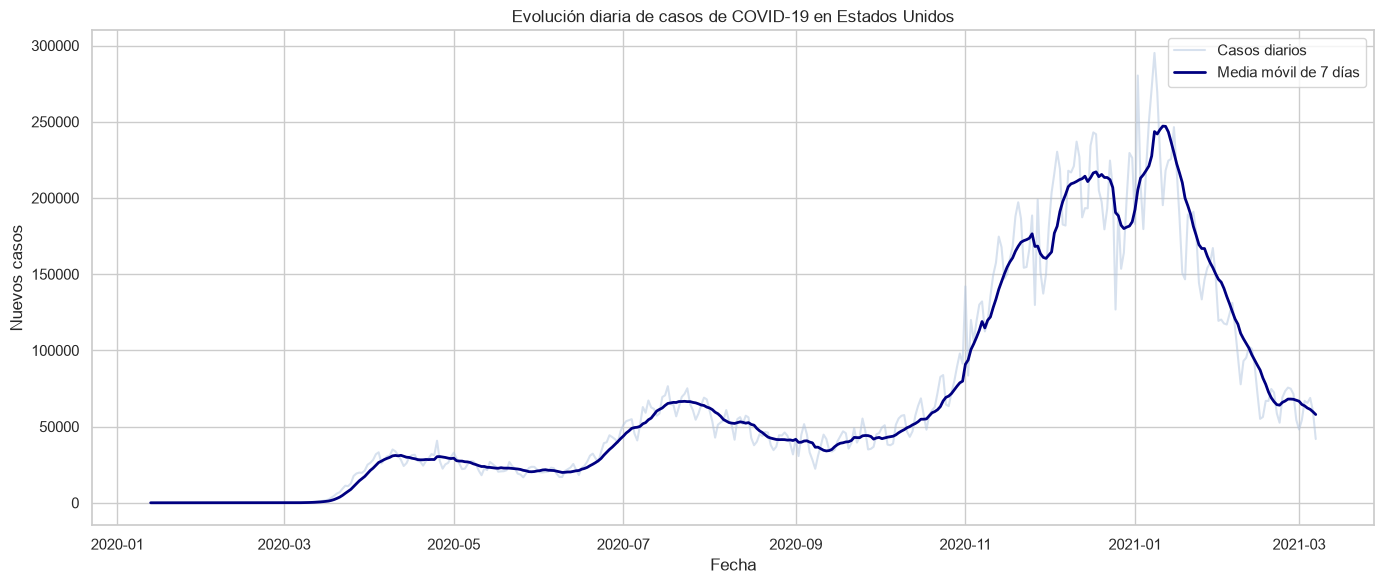

In [19]:
sns.set_theme(style="whitegrid")

FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    evolucion_nacional["date"],
    evolucion_nacional["nuevos_casos"],
    color="lightsteelblue",
    alpha=0.5,
    label="Casos diarios",
)

ax.plot(
    evolucion_nacional["date"],
    evolucion_nacional["media_7d_casos"],
    color="navy",
    linewidth=2,
    label="Media móvil de 7 días",
)

ax.set_title("Evolución diaria de casos de COVID-19 en Estados Unidos")
ax.set_xlabel("Fecha")
ax.set_ylabel("Nuevos casos")
ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "evolucion_casos_usa.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [20]:
pico_casos = evolucion_nacional.loc[
    evolucion_nacional["media_7d_casos"].idxmax()
]

print(f"Fecha del pico: {pico_casos['date']:%d/%m/%Y}")
print(f"Media de casos diarios: {pico_casos['media_7d_casos']:,.0f}")

Fecha del pico: 11/01/2021
Media de casos diarios: 247,111


### Hallazgo principal

La mayor ola de contagios se produjo durante el invierno de 2020-2021. El máximo de la media móvil de siete días se alcanzó el 11 de enero de 2021, con aproximadamente 247.111 nuevos casos diarios.

La media móvil permite observar mejor la tendencia al reducir las variaciones provocadas por retrasos y diferencias en la notificación diaria.

### Evolución de los fallecimientos

Analizamos los fallecimientos diarios mediante una media móvil de siete días para identificar la etapa más crítica de la pandemia.

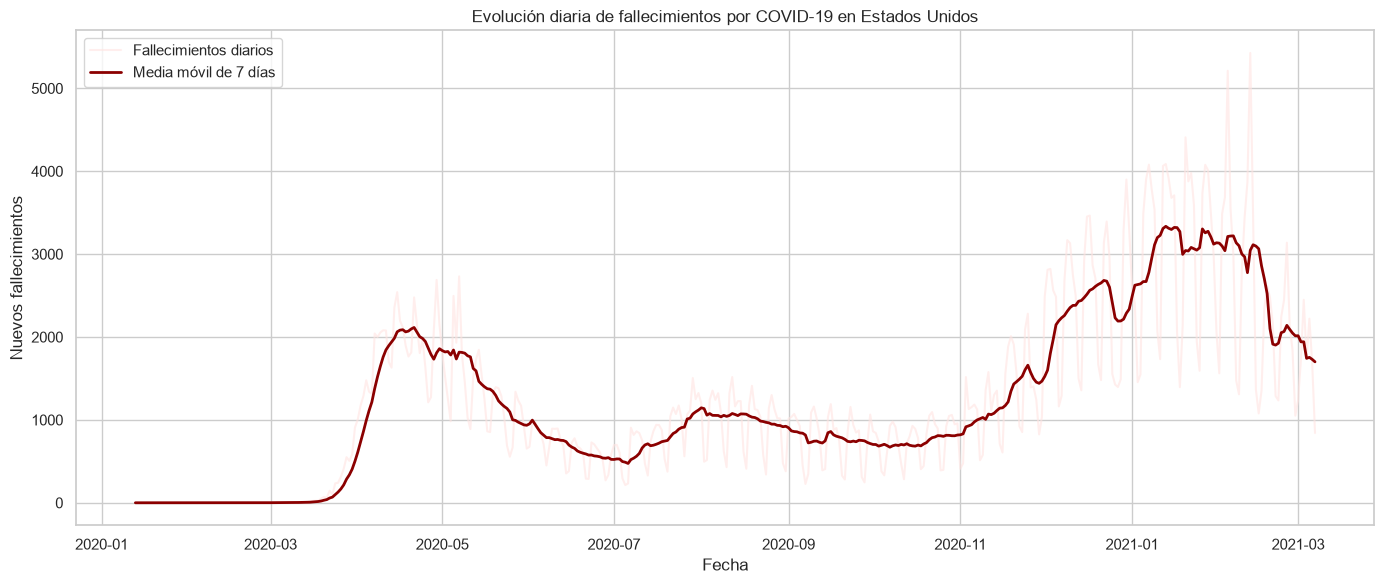

Fecha del pico: 13/01/2021
Media de fallecimientos diarios: 3,335


In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    evolucion_nacional["date"],
    evolucion_nacional["nuevos_fallecimientos"],
    color="mistyrose",
    alpha=0.6,
    label="Fallecimientos diarios",
)

ax.plot(
    evolucion_nacional["date"],
    evolucion_nacional["media_7d_fallecimientos"],
    color="darkred",
    linewidth=2,
    label="Media móvil de 7 días",
)

ax.set_title("Evolución diaria de fallecimientos por COVID-19 en Estados Unidos")
ax.set_xlabel("Fecha")
ax.set_ylabel("Nuevos fallecimientos")
ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "evolucion_fallecimientos_usa.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

pico_fallecimientos = evolucion_nacional.loc[
    evolucion_nacional["media_7d_fallecimientos"].idxmax()
]

print(f"Fecha del pico: {pico_fallecimientos['date']:%d/%m/%Y}")
print(
    "Media de fallecimientos diarios: "
    f"{pico_fallecimientos['media_7d_fallecimientos']:,.0f}"
)

### Hallazgo principal

La media móvil alcanzó su máximo el 13 de enero de 2021, con aproximadamente 3.335 fallecimientos diarios.

El máximo registrado coincide con la gran ola del invierno de 2020-2021. Aunque aparece dos días después del pico estadístico de casos, esta diferencia no representa el tiempo clínico entre contagio y fallecimiento, ya que los datos están condicionados por retrasos y correcciones en la notificación.

## 6. Comparación entre estados

Comparamos los casos acumulados al final del periodo. Se excluyen los cinco territorios, pero se mantiene Washington D. C.

Estos valores reflejan el volumen total registrado y no el impacto proporcional sobre la población.

In [22]:
territorios = ["AS", "GU", "MP", "PR", "VI"]

ultimo_registro = (
    df_clean.loc[~df_clean["state"].isin(territorios)]
    .sort_values("date")
    .groupby("state", as_index=False)
    .tail(1)
)

top_casos = (
    ultimo_registro.nlargest(10, "positive")
    [["state", "positive"]]
    .sort_values("positive")
)

top_casos

,state,positive
1825,AZ,826454.0
11455,NC,872176.0
15549,PA,948643.0
14444,OH,978471.0
4444,GA,1023487.0
6272,IL,1198335.0
14076,NY,1681169.0
4075,FL,1909209.0
17751,TX,2686818.0
2194,CA,3501394.0


### Estados con más casos acumulados

California, Texas y Florida encabezan el número absoluto de casos registrados. Sin embargo, esta comparación no está ajustada por población, por lo que representa el volumen total y no el riesgo individual.

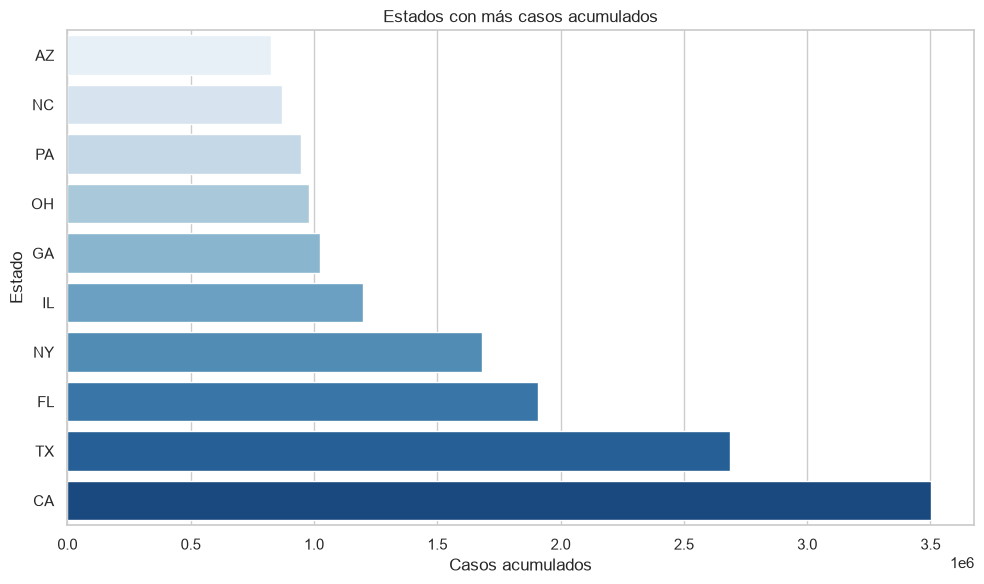

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top_casos,
    x="positive",
    y="state",
    hue="state",
    palette="Blues",
    legend=False,
    ax=ax,
)

ax.set_title("Estados con más casos acumulados")
ax.set_xlabel("Casos acumulados")
ax.set_ylabel("Estado")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "top_10_estados_casos.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Estados con más fallecimientos acumulados

Se comparan los fallecimientos totales registrados hasta el final del periodo. Al igual que con los casos, son valores absolutos sin ajustar por población.

In [24]:
top_fallecimientos = (
    ultimo_registro.nlargest(10, "death")
    [["state", "death"]]
    .sort_values("death")
)

top_fallecimientos

,state,death
9264,MI,16658.0
14444,OH,17656.0
4444,GA,17906.0
6272,IL,23014.0
12969,NJ,23574.0
15549,PA,24349.0
4075,FL,32266.0
14076,NY,39029.0
17751,TX,44451.0
2194,CA,54124.0


### Interpretación

California y Texas encabezan tanto los casos como los fallecimientos acumulados. Nueva York ocupa el tercer lugar en fallecimientos pese a situarse por detrás de Florida en casos.

Esto podría estar relacionado con el fuerte impacto sufrido por Nueva York durante la primera ola, aunque para comparar la gravedad entre estados sería necesario ajustar los datos por población y considerar diferencias temporales y de notificación.

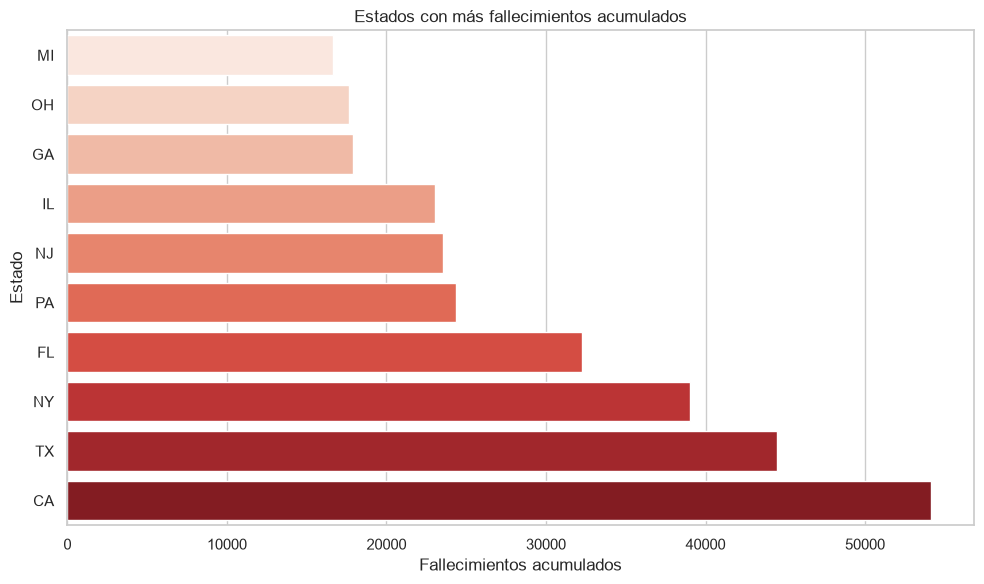

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top_fallecimientos,
    x="death",
    y="state",
    hue="state",
    palette="Reds",
    legend=False,
    ax=ax,
)

ax.set_title("Estados con más fallecimientos acumulados")
ax.set_xlabel("Fallecimientos acumulados")
ax.set_ylabel("Estado")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "top_10_estados_fallecimientos.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()